#### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Fetching

In [2]:
df=pd.read_excel("bioactivity_dataset.xlsx", sheet_name="Sheet1")
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


#### Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6629 entries, 0 to 6628
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  6629 non-null   object 
 1   canonical_smiles    6628 non-null   object 
 2   MW                  6629 non-null   float64
 3   LogP                6629 non-null   float64
 4   NumHDonors          6629 non-null   int64  
 5   NumHAcceptors       6629 non-null   int64  
 6   pIC50               6629 non-null   float64
 7   bioactivity_class   6629 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 414.4+ KB


In [4]:
df.describe(include='all')

c:\BioActivity\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6629.00,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,inf,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,NaN,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.39,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.17,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.88,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.60,NaN


In [5]:
df['pIC50']=df['pIC50'].replace(['inf', np.inf], np.nan)
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6627.000000,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,6.752300,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,1.286299,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.170000,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.880000,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.600000,NaN


In [6]:
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      1
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 2
bioactivity_class     0
dtype: int64

In [7]:
df.dropna(inplace=True)
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      0
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 0
bioactivity_class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(285)

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(['molecule_chembl_id'], axis=1, inplace=True)

In [11]:
df.to_excel("bioactivity_dataset_cleaned.xlsx", index=False)

#### Data Analysis

In [12]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [13]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
Categorical Columns: ['canonical_smiles', 'bioactivity_class']


In [14]:
df[categorical_cols].nunique()

canonical_smiles     5470
bioactivity_class       2
dtype: int64

In [15]:
from rdkit import Chem

invalid_smiles_mask = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is None)
invalid_smiles = df[invalid_smiles_mask]

print(f"Number of invalid SMILES: {invalid_smiles_mask.sum()}")

Number of invalid SMILES: 0


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

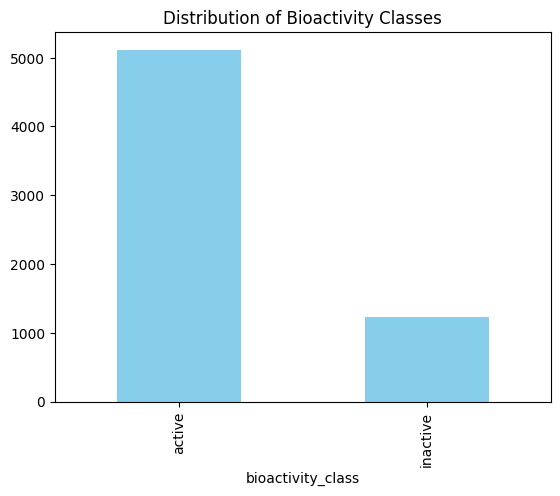

In [16]:
df['bioactivity_class'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [17]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6341,6341.000000,6341.000000,6341.000000,6341.000000,6341.000000,6341
unique,5470,NaN,NaN,NaN,NaN,NaN,2
top,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,247,NaN,NaN,NaN,NaN,NaN,5118
mean,NaN,423.154674,3.607172,2.886296,5.617726,6.739003,NaN
std,NaN,120.324203,1.446058,1.146729,2.446312,1.297159,NaN
min,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,345.786000,2.579300,2.000000,4.000000,6.150000,NaN
50%,NaN,405.477000,3.520340,3.000000,5.000000,6.860000,NaN
75%,NaN,484.603000,4.485520,3.000000,7.000000,7.600000,NaN


#### Feature Transformation

In [3]:
df_cleaned=pd.read_excel("bioactivity_dataset_cleaned.xlsx", sheet_name="Sheet1")
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [4]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bioactivity_class'], drop_first=True)
df_cleaned.head(5)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False
3,O=C(CCCCCCC(=O)Nc1ccccc1)NO,264.325,2.4711,3,3,6.7,False
4,O=C(CCCCCC/C(=N\O)c1ccc(-c2ccccc2)cc1)NO,340.423,4.3779,3,4,8.4,False


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

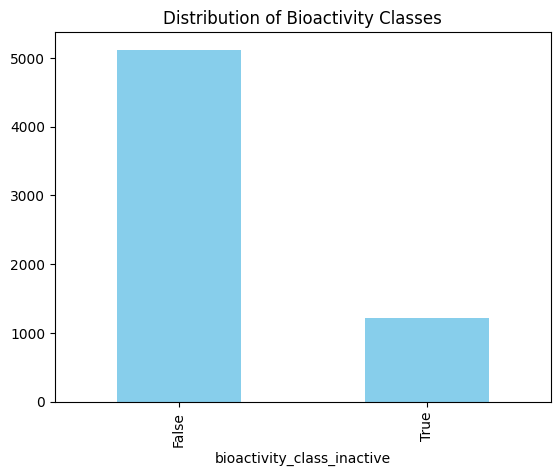

In [5]:
df_cleaned['bioactivity_class_inactive'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [6]:
features_df = df_cleaned.drop(['bioactivity_class_inactive', 'pIC50'], axis=1)
target_df = df_cleaned['bioactivity_class_inactive']

In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   canonical_smiles            6341 non-null   object 
 1   MW                          6341 non-null   float64
 2   LogP                        6341 non-null   float64
 3   NumHDonors                  6341 non-null   int64  
 4   NumHAcceptors               6341 non-null   int64  
 5   pIC50                       6341 non-null   float64
 6   bioactivity_class_inactive  6341 non-null   bool   
dtypes: bool(1), float64(3), int64(2), object(1)
memory usage: 303.6+ KB


In [ ]:
# smiles= features_df['canonical_smiles']

In [8]:
numerical_cols= features_df.select_dtypes(include=[np.number]).columns.tolist()

In [9]:
numerical_cols

['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

Text(0.5, 1.0, 'Boxplots of Numerical Features')

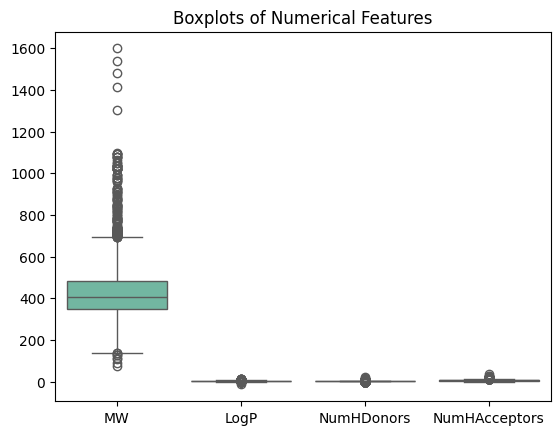

In [10]:
sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

In [12]:
# # Calculate Q1 (25th percentile) and Q3 (75th percentile) for each column
# Q1 = features_df[numerical_cols].quantile(0.25)
# Q3 = features_df[numerical_cols].quantile(0.75)

# # Calculate the IQR for each column
# IQR = Q3 - Q1

# # Define the lower and upper bounds for outliers
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Identify rows where the data points are outside the bounds
# outliers = ((features_df[numerical_cols] < lower_bound) | (features_df[numerical_cols] > upper_bound)).any(axis=1)

# # Remove outliers from the dataset
# features_df = features_df[~outliers]

# # Check the result
# print(f"Original dataset size: {features_df.shape[0]}")
# print(f"Dataset size after removing outliers: {features_df.shape[0]}")

#features_df=features_df.copy()


Text(0.5, 1.0, 'Boxplots of Numerical Features')

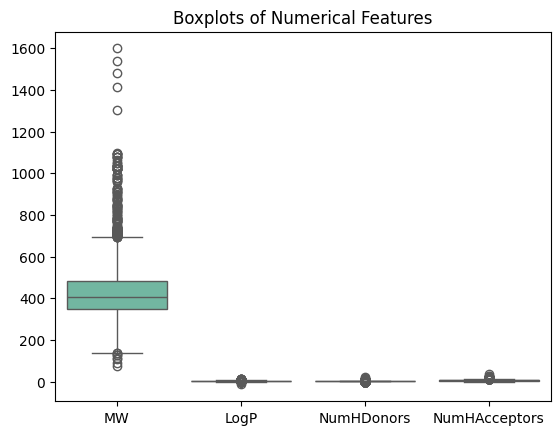

In [11]:

sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

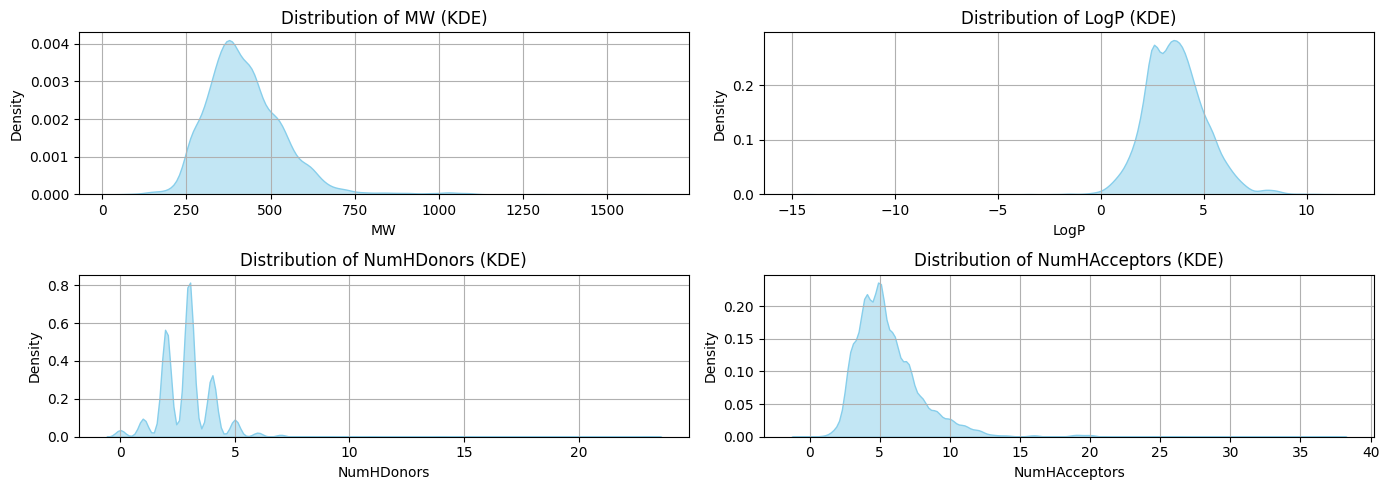

In [12]:

# If there are more than one plot, arrange two plots per row
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Distribution of {col} (KDE)')
    sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

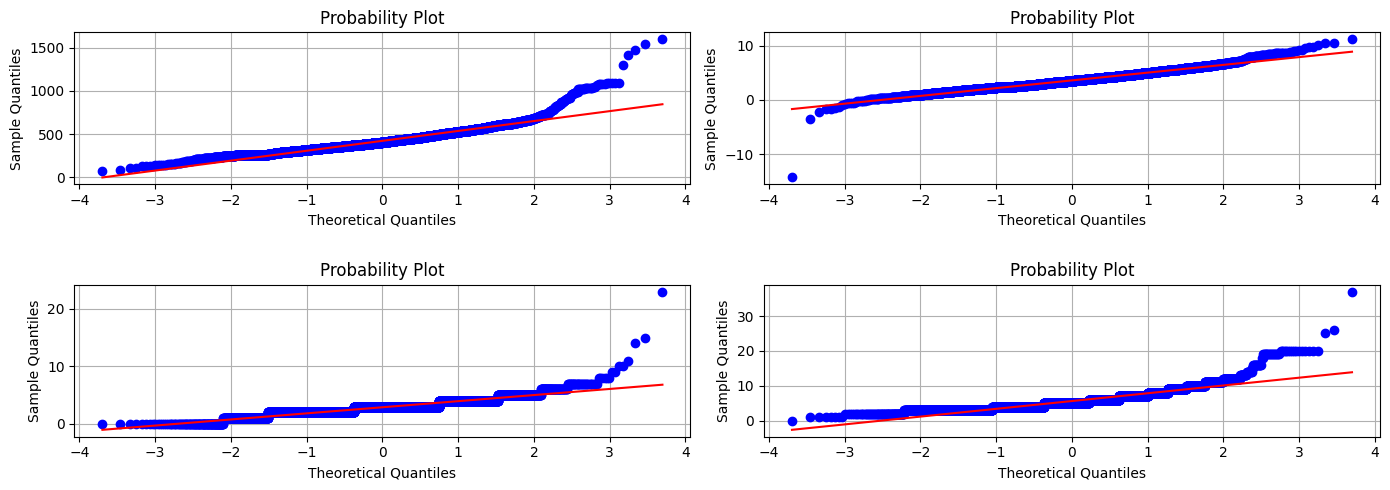

In [13]:
import scipy.stats as stats

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Q-Q Plot of {col}')
    stats.probplot(features_df[col], dist="norm", plot=axes[i])
    axes[i].set_xlabel('Theoretical Quantiles')
    # Add gap between rows by increasing vertical space between subplots
    plt.tight_layout(h_pad=2.5)
    axes[i].set_ylabel('Sample Quantiles')
    axes[i].grid()

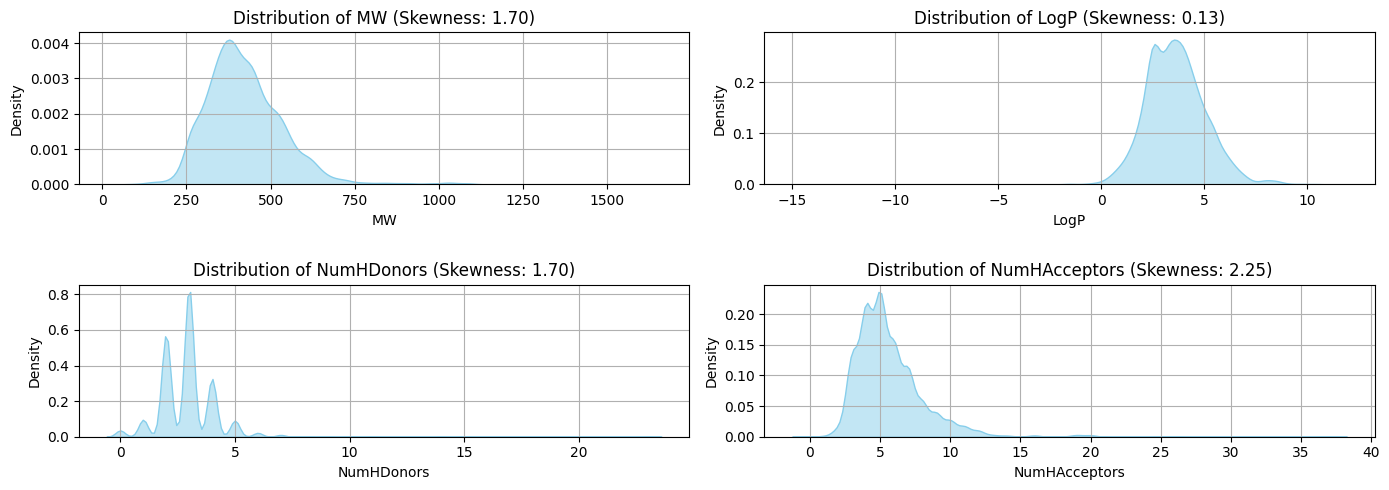

In [18]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [19]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=2536.683, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=3107.232, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=3327.011, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [20]:
import scipy

features_df['MW']=np.log(features_df['MW']+1)
features_df['NumHDonors']=np.log(features_df['NumHDonors']+1)
features_df['NumHAcceptors']=np.log(features_df['NumHAcceptors']+1)

In [21]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [22]:
for col in numerical_cols:
    features_df[col] = (features_df[col] - features_df[col].mean()) / features_df[col].std()
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [23]:
for col in numerical_cols:
    skewness = stats.skew(features_df[col])  # Calculate skewness
    print(f'Skewness of {col}: {skewness:.2f}')
    
    if abs(skewness) > 0.5:
        print(f'{col} is significantly skewed (|Skewness| > 0.5)')
    else:
        print(f'{col} is approximately symmetric (|Skewness| <= 0.5)')

Skewness of MW: 0.03
MW is approximately symmetric (|Skewness| <= 0.5)
Skewness of LogP: 0.13
LogP is approximately symmetric (|Skewness| <= 0.5)
Skewness of NumHDonors: -1.15
NumHDonors is significantly skewed (|Skewness| > 0.5)
Skewness of NumHAcceptors: 0.47
NumHAcceptors is approximately symmetric (|Skewness| <= 0.5)


In [24]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


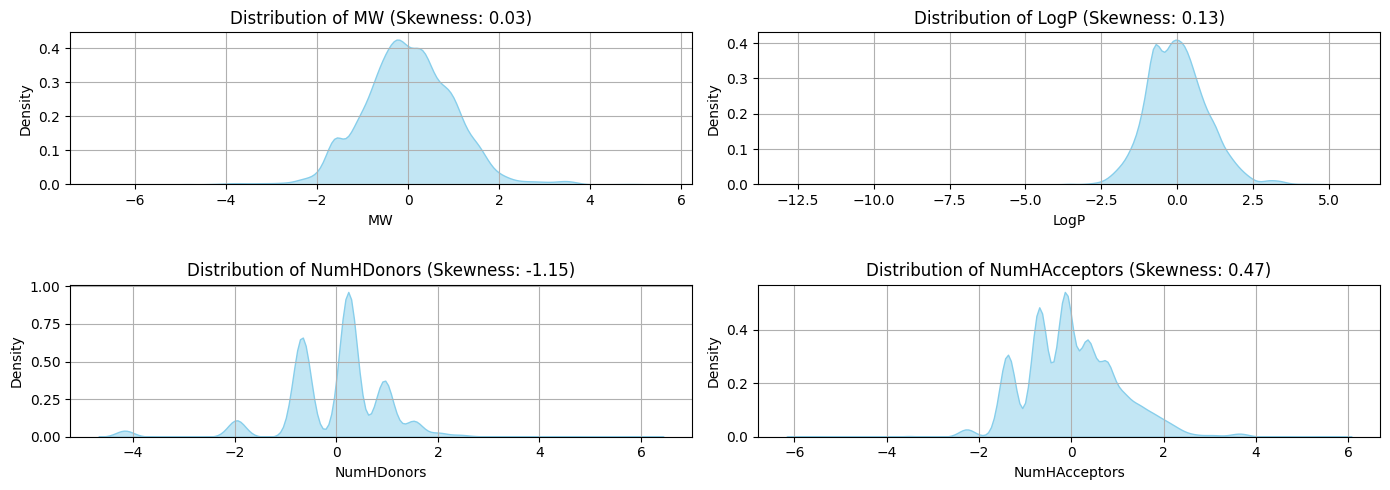

In [25]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [26]:
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [27]:
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False


##### RDKit

In [14]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)


##### DeepChem

In [27]:
%pip install deepchem

import deepchem as dc
from rdkit import Chem

# Use DeepChem's MolGraphConvFeaturizer to convert SMILES to molecular graph features
featurizer = dc.feat.MolGraphConvFeaturizer()

# This will create a list of graph features for each molecule
features_df['molecular_graph'] = features_df['canonical_smiles'].apply(lambda x: featurizer.featurize([x])[0])

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\BioActivity\.venv\Lib\site-packages\deepchem\feat\smiles_tokenizer.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ModuleNotFoundError: No module named 'tensorflow'

In [40]:
features_df=features_df.drop(['canonical_smiles'], axis=1)

In [42]:
features_df.head(3)

,MW,LogP,NumHDonors,NumHAcceptors,molecular_graph
0,0.483099,0.219236,0.943334,0.344859,"GraphData(node_features=[34, 30], edge_index=[..."
1,0.648027,0.570605,0.943334,0.344859,"GraphData(node_features=[36, 30], edge_index=[..."
2,0.067137,-0.028334,0.943334,-0.692281,"GraphData(node_features=[31, 30], edge_index=[..."


In [44]:
features_df["graph_features"] = [graph.node_features for graph in features_df['molecular_graph']]
features_df.drop(['molecular_graph'], axis=1, inplace=True)
features_df.head(3)

,MW,LogP,NumHDonors,NumHAcceptors,graph_features
0,0.483099,0.219236,0.943334,0.344859,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,0.648027,0.570605,0.943334,0.344859,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


##### ChemBERTa

In [49]:
from transformers import BertModel, AutoTokenizer
import torch

# Load pretrained ChemBERTa model (PyTorch version)
model = BertModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

# Encode the SMILES string into embeddings
def get_chemberta_embedding(smiles):
    inputs = tokenizer(smiles, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()

features_df['chemberta_embedding'] = features_df['canonical_smiles'].apply(get_chemberta_embedding)


You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertModel were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.

In [50]:
features_df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."


In [52]:
features_df['chemberta_embedding'][0].shape

(1, 768)

In [53]:
X=features_df.drop(['canonical_smiles'], axis=1)

In [54]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [57]:
print(X.shape, y.shape)

(6341, 5) (6341,)


In [58]:
X

,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."
3,-1.616230,-0.785634,0.234994,-1.380096,"[[0.020684434, 0.4703463, 0.16719496, 0.629871..."
4,-0.674613,0.532985,0.234994,-0.692281,"[[-0.27644372, 0.5241341, 0.23280697, 0.511133..."
...,...,...,...,...,...
6336,-0.556850,-0.909211,0.234994,-0.130294,"[[-0.3302253, 0.6001225, 0.21501105, 0.2417253..."
6337,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.30155748, 0.66687113, 0.18498448, 0.31351..."
6338,-0.023540,0.483125,0.234994,0.756455,"[[-0.23910008, 0.5743231, 0.25488824, 0.486559..."
6339,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.38627326, 0.6163624, 0.15096714, 0.402964..."


In [61]:
first_embedding = np.array(X['chemberta_embedding'].iloc[0])
print(f"Shape of a single embedding: {first_embedding.shape}")

Shape of a single embedding: (1, 768)


In [64]:
def squeeze_embedding(embedding_list):
    """
    Squeezes a pre-pooled embedding of shape (1, d) into shape (d,)
    """
    return np.array(embedding_list).squeeze() # .squeeze() removes dimensions of size 1

# Apply the function to the whole column
X['squeezed_embedding'] = X['chemberta_embedding'].apply(squeeze_embedding)

# 3. Create the final feature set
# Get the traditional features
traditional_features = X[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']].values

# Stack the squeezed embeddings into a matrix
embedding_matrix = np.vstack(X['squeezed_embedding'].values)

# Combine them by concatenating the columns
final_feature_matrix = np.hstack((traditional_features, embedding_matrix))

print(f"Traditional features shape: {traditional_features.shape}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Final combined feature matrix shape: {final_feature_matrix.shape}")

Traditional features shape: (6341, 4)
Embedding matrix shape: (6341, 768)
Final combined feature matrix shape: (6341, 772)


In [89]:
# Extract the embeddings and convert them into a usable format (e.g., an array)
embeddings = np.array(X['chemberta_embedding'].tolist())
embeddings.shape

(6341, 1, 768)

#### Model Training

In [3]:
cleaned_df=pd.read_excel("bioactivity_dataset_cleaned_outliers.xlsx")
cleaned_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,1


In [4]:
features_df = cleaned_df.drop(['bioactivity_class', 'bioactivity','pIC50'], axis=1)
target_df = cleaned_df['bioactivity']

In [7]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)
X.shape

(5667, 1004)

In [5]:
len(features_df), len(target_df)

(5667, 5667)

In [8]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [9]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4533, 1004) (4533,)
(1134, 1004) (1134,)


##### XGBoost

In [10]:
import optuna
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "verbosity": 0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "use_label_encoder": False,
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
    }
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return 1.0 - accuracy  # Optuna minimizes, so invert accuracy

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({"objective": "binary:logistic", "eval_metric": "logloss", "use_label_encoder": False})
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-09-14 00:24:31,359] A new study created in memory with name: no-name-a3ce0cc8-e8f7-4e7f-99d4-e5ff4dc179fe
[I 2025-09-14 00:24:32,267] Trial 0 finished with value: 0.13492063492063489 and parameters: {'max_depth': 3, 'learning_rate': 0.05324117158777635, 'n_estimators': 94, 'subsample': 0.8786473269350847, 'colsample_bytree': 0.514134296573024, 'gamma': 2.0410935852402714, 'reg_alpha': 3.355213526439371, 'reg_lambda': 1.1964303964894056}. Best is trial 0 with value: 0.13492063492063489.
[I 2025-09-14 00:24:33,662] Trial 1 finished with value: 0.0978835978835979 and parameters: {'max_depth': 10, 'learning_rate': 0.024337926802488054, 'n_estimators': 170, 'subsample': 0.7757961067840988, 'colsample_bytree': 0.637192857413944, 'gamma': 0.3

Best trial:
FrozenTrial(number=39, state=1, values=[0.06701940035273368], datetime_start=datetime.datetime(2025, 9, 14, 0, 25, 15, 83356), datetime_complete=datetime.datetime(2025, 9, 14, 0, 25, 16, 202601), params={'max_depth': 6, 'learning_rate': 0.21617788854577139, 'n_estimators': 175, 'subsample': 0.7210316638793167, 'colsample_bytree': 0.5519367917084741, 'gamma': 0.3547790487217682, 'reg_alpha': 0.7480575615901046, 'reg_lambda': 4.519787046124753}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'n_estimators': IntDistribution(high=300, log=False, low=50, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=None), 'reg_alpha': FloatDistribution(hig

Text(95.72222222222221, 0.5, 'Actual')

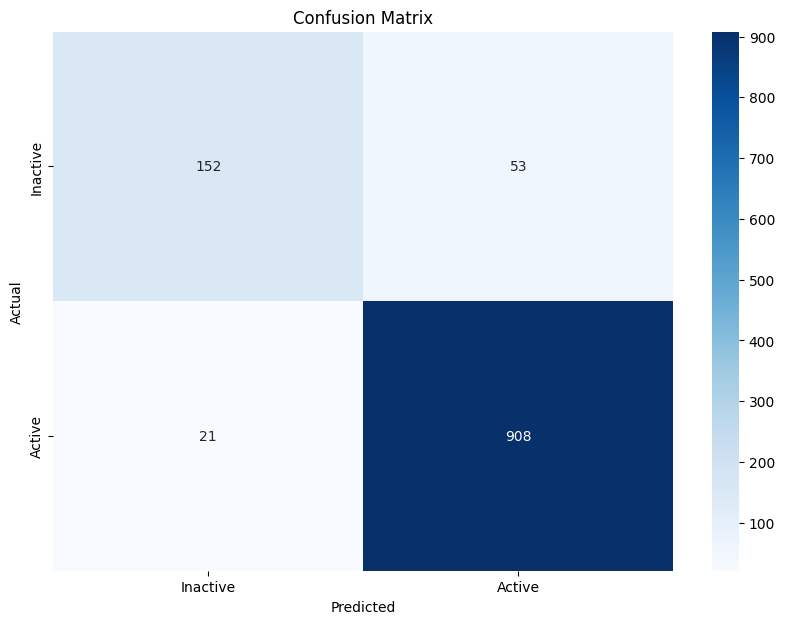

In [27]:
conf_matrix = confusion_matrix(y_test, y_pred)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [2]:
# import joblib
# joblib.dump(final_model, r"models\xgboost_bioactivity_model.pkl")

In [12]:
import joblib
from sklearn.metrics import balanced_accuracy_score
# fmodel = joblib.load(r"models\xgboost_bioactivity_model.pkl")
y_test_pred = final_model.predict(X_test)
print("Loaded Model Accuracy:", balanced_accuracy_score(y_test, y_test_pred))

Loaded Model Accuracy: 0.8507495602404893


#### RandomForest

In [13]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.5, 1]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42
    }
    model = RandomForestClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return 1.0 - accuracy  # Optuna minimizes, so invert accuracy

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
final_model = RandomForestClassifier(**best_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-09-14 00:28:18,209] A new study created in memory with name: no-name-b1f1abd2-5dd4-4624-b7ce-d39955d74a7e
[I 2025-09-14 00:28:47,233] Trial 0 finished with value: 0.09523809523809523 and parameters: {'n_estimators': 293, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}. Best is trial 0 with value: 0.09523809523809523.
[I 2025-09-14 00:28:47,233] Trial 0 finished with value: 0.09523809523809523 and parameters: {'n_estimators': 293, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}. Best is trial 0 with value: 0.09523809523809523.
[I 2025-09-14 00:29:16,582] Trial 1 finished with value: 0.1049382716049383 and parameters: {'n_estimators': 263, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': False}. Best is trial 0 with value: 0.09523809523809523.
[I 2025-09-14 00:29:16,582] Trial 1 finished with value: 0.1049382716049383 and

Best trial:
FrozenTrial(number=23, state=1, values=[0.09082892416225752], datetime_start=datetime.datetime(2025, 9, 14, 0, 33, 48, 94646), datetime_complete=datetime.datetime(2025, 9, 14, 0, 34, 5, 201700), params={'n_estimators': 175, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=300, log=False, low=50, step=1), 'max_depth': IntDistribution(high=20, log=False, low=3, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None, 0.5, 1)), 'bootstrap': CategoricalDistribution(choices=(True, False))}, trial_id=23, value=None)
Best params: {'n_estimators': 175, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}
F

Text(95.72222222222221, 0.5, 'Actual')

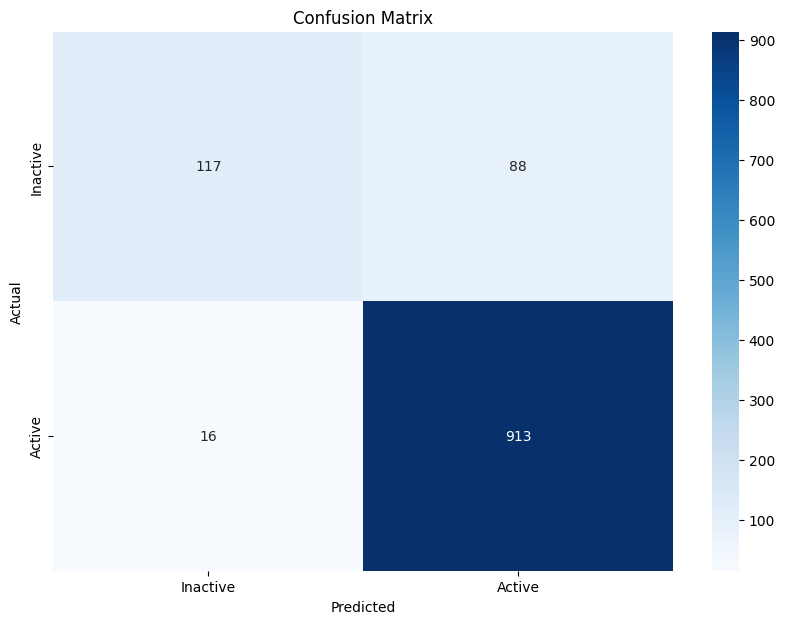

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [15]:
import joblib
joblib.dump(final_model, r"models\\randomforest_classifier_model.pkl")

['models\\\\randomforest_classifier_model.pkl']

In [16]:
#final_model = joblib.load(r"models\\randomforest_classifier_model.pkl")
#print("Model loaded successfully.")
print("Accuracy:", balanced_accuracy_score(y_test, final_model.predict(X_test)))

Accuracy: 0.7767544435401297


In [17]:
from sklearn.metrics import log_loss

# Calculate log loss
log_loss_value = log_loss(y_test, final_model.predict_proba(X_test))
print("Log Loss:", log_loss_value)

log_loss_value = log_loss(y_train, final_model.predict_proba(X_train))
print("Log Loss:", log_loss_value)

# Focal Loss for Imbalanced Data (Test Set)
import numpy as np
import torch
import torch.nn as nn

# Focal Loss implementation (binary classification)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

# Get predicted probabilities for the positive class
y_proba = final_model.predict_proba(X_test)[:, 1]
# Convert to logits (inverse of sigmoid)
eps = 1e-8  # to avoid log(0)
logits = np.log(y_proba / (1 - y_proba + eps) + eps)

# Convert to torch tensors
logits_tensor = torch.tensor(logits, dtype=torch.float32)
targets_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Calculate focal loss
focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
focal_loss_value = focal_loss_fn(logits_tensor, targets_tensor)
print(f'Focal Loss (Test Set): {focal_loss_value.item():.4f}')

Log Loss: 0.23412864061277228
Log Loss: 0.11529912094296614
Focal Loss (Test Set): 0.0259
Focal Loss (Test Set): 0.0259


In [27]:
y_train.value_counts()

bioactivity_class_inactive
False    4094
True      978
Name: count, dtype: int64

#### LightGBM

In [19]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import optuna
import lightgbm as lgbm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "objective": "binary",
        "metric": "binary_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 7, 128),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
    }
    model = lgbm.LGBMClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return 1.0 - accuracy  # Optuna minimizes, so invert accuracy

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({"objective": "binary", "metric": "binary_logloss", "verbosity": -1})
final_model = lgbm.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-09-14 01:41:49,868] A new study created in memory with name: no-name-7233c1d8-1593-4714-8817-3073ab25d3f8
[I 2025-09-14 01:41:52,329] Trial 0 finished with value: 0.12874779541446213 and parameters: {'max_depth': 12, 'num_leaves': 108, 'learning_rate': 0.02731885504601602, 'n_estimators': 84, 'subsample': 0.6413794792387808, 'colsample_bytree': 0.9717422596743802, 'reg_alpha': 4.329078706851476, 'reg_lambda': 4.053222768340369, 'min_child_samples': 46}. Best is trial 0 with value: 0.12874779541446213.
[I 2025-09-14 01:41:52,329] Trial 0 finished with value: 0.12874779541446213 and parameters: {'max_depth': 12, 'num_leaves': 108, 'learning_rate': 0.02731885504601602, 'n_estimators': 84, 'subsample': 0.6413794792387808, 'colsample_bytree': 0.9717422596743802, 'reg_alpha': 4.329078706851476, 'reg_lambda': 4.053222768340369, 'min_child_samples': 46}. Best is trial 0 with value: 0.12874779541446213.
[I 2025-09-14 01:41:52,811] Trial 1 finished with value: 0.1807760141093474 and para

Best trial:
FrozenTrial(number=41, state=1, values=[0.06525573192239864], datetime_start=datetime.datetime(2025, 9, 14, 1, 42, 6, 651007), datetime_complete=datetime.datetime(2025, 9, 14, 1, 42, 7, 390052), params={'max_depth': 12, 'num_leaves': 94, 'learning_rate': 0.19507520710174014, 'n_estimators': 232, 'subsample': 0.9681383632369072, 'colsample_bytree': 0.5292752086337411, 'reg_alpha': 0.4156414493866226, 'reg_lambda': 1.5016980909968232, 'min_child_samples': 11}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'num_leaves': IntDistribution(high=128, log=False, low=7, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'n_estimators': IntDistribution(high=300, log=False, low=50, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'reg_alpha': FloatDis

Text(95.72222222222221, 0.5, 'Actual')

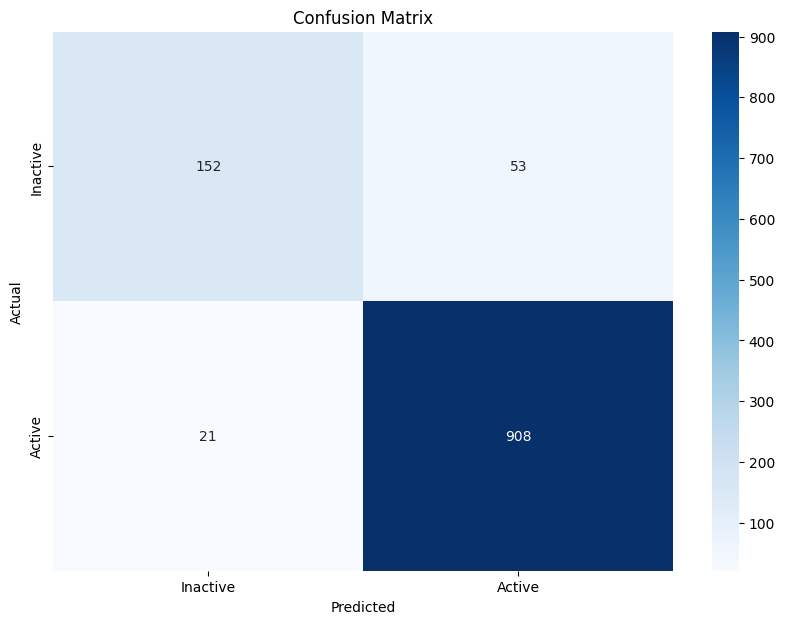

In [21]:
conf_matrix = confusion_matrix(y_test, y_pred)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [22]:
import joblib
joblib.dump(final_model, r"models\\lightgbm_classifier_model.pkl")

['models\\\\lightgbm_classifier_model.pkl']

In [26]:
# final_model = joblib.load(r"models\\lightgbm_classifier_model.pkl")
# print("Model loaded successfully.")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, final_model.predict(X_test)))

Balanced Accuracy: 0.8594292315366641
